# 딥러닝 기초 4일차 실습과제: CNN과 전이학습

## 과제 개요
의료 이미지 데이터셋(MedMNIST)을 활용하여 CNN을 직접 구현하고, 전이학습(Feature Extraction / Fine-tuning)을 적용해 비교한다.

### 사용 데이터셋
- MedMNIST BreastMNIST (유방 초음파 이미지, 2 클래스 이진 분류) — CPU 환경에서도 학습이 끝나도록 MedMNIST 중 가장 작은 서브셋을 선택했다.

### 학습 목표
1. CNN 모델 설계 및 구현
2. 데이터 증강(Augmentation) 적용
3. 전이학습(Transfer Learning) 적용 — Feature Extraction / Fine-tuning
4. Feature Extraction vs Fine-tuning 비교
5. 성능 비교 리포트 작성


## Part 0: 환경 설정 및 데이터 다운로드

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [2]:
# MedMNIST BreastMNIST: 유방 초음파 이미지, 2 클래스(malignant / normal,benign)
# CPU에서도 현실적인 시간 안에 여러 모델(SimpleCNN, Feature Extraction, Fine-tuning, EfficientNet)을
# 비교 실험하기 위해 MedMNIST 중 가장 작은 서브셋(BreastMNIST, 780장)을 선택했다.
import medmnist
from medmnist import INFO

MEDMNIST_TYPE = "breastmnist"
info = INFO[MEDMNIST_TYPE]

print(f"{MEDMNIST_TYPE.upper()} 데이터셋 정보:")
print(f" - 설명: {info['description']}")
print(f" - 클래스 목록: {info['label']}")

DataClass = getattr(medmnist, info['python_class'])
NUM_CLASSES = len(info['label'])
CLASS_NAMES = list(info['label'].values())


BREASTMNIST 데이터셋 정보:
 - 설명: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
 - 클래스 목록: {'0': 'malignant', '1': 'normal, benign'}


## Part 1: 데이터 로드 및 전처리

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def to_rgb(x):
    """그레이스케일(1채널)을 RGB(3채널)로 변환"""
    if x.shape[0] == 1:
        return x.repeat(3, 1, 1)
    return x

# 28x28 -> 224x224 리사이즈 (사전학습 모델과 호환되도록)
medmnist_transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

medmnist_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

DATA_ROOT = "medmnist_data"

train_dataset = DataClass(split='train', transform=medmnist_transform_train, download=True, root=DATA_ROOT)
val_dataset = DataClass(split='val', transform=medmnist_transform_test, download=True, root=DATA_ROOT)
test_dataset = DataClass(split='test', transform=medmnist_transform_test, download=True, root=DATA_ROOT)

print(f"Train set: {len(train_dataset):,} samples")
print(f"Validation set: {len(val_dataset):,} samples")
print(f"Test set: {len(test_dataset):,} samples")


Train set: 546 samples
Validation set: 78 samples
Test set: 156 samples


In [4]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")


Number of batches - Train: 35, Val: 5, Test: 10


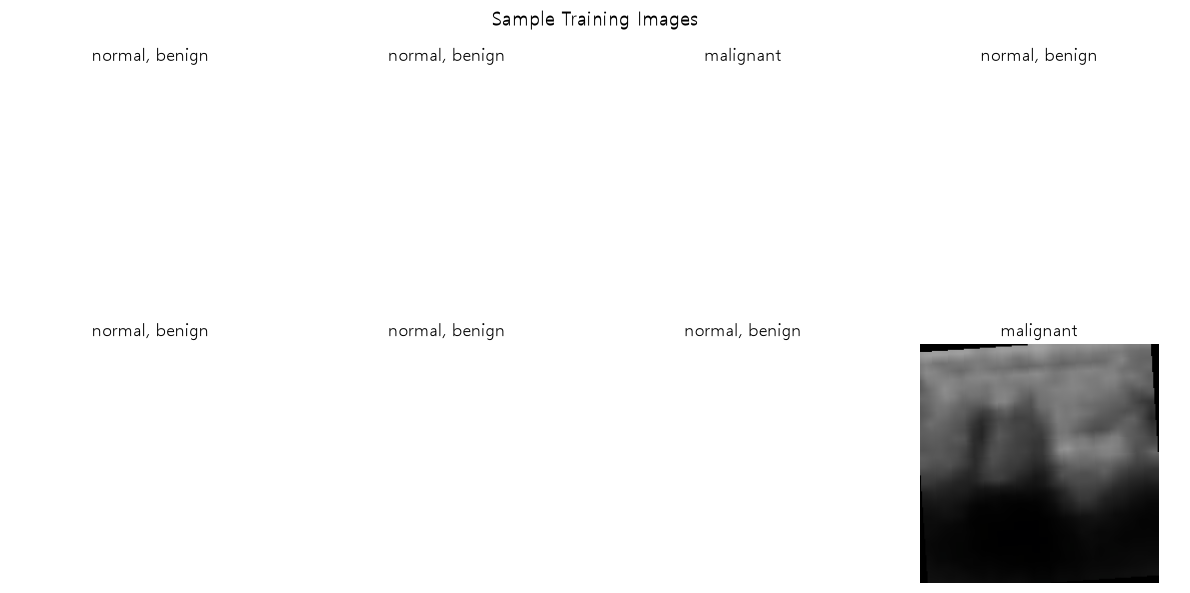

In [5]:
def imshow(img, title=None):
    """이미지 시각화 (정규화 역변환 포함)"""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.axis('off')
    imshow(images[i])
    ax.set_title(f'{CLASS_NAMES[int(labels[i])]}')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()


## Part 2: 기본 CNN 모델 구현

In [6]:
class SimpleCNN(nn.Module):
    """기본 CNN 모델"""
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


In [7]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        if len(labels.shape) > 1:
            labels = labels.squeeze(1)
        labels = labels.long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            if len(labels.shape) > 1:
                labels = labels.squeeze(1)
            labels = labels.long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(val_loader), correct / total


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                 scheduler=None, num_epochs=20, patience=5, device='cpu'):
    """전체 학습 루프 (Early Stopping 포함)"""
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_acc = 0.0
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 3 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
                  f"Train: {train_loss:.4f}/{train_acc:.4f} | "
                  f"Val: {val_loss:.4f}/{val_acc:.4f} | LR: {current_lr:.6f}")

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"Best model restored (Val Acc: {best_val_acc:.4f})")

    return model, history


def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history['train_loss'], label='Train', color='#8FBC8F')
    axes[0].plot(history['val_loss'], label='Val', color='#87CEEB')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', color='#8FBC8F')
    axes[1].plot(history['val_acc'], label='Val', color='#87CEEB')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


기본 CNN 모델 학습


Epoch [ 3/15] | Train: 0.5712/0.7179 | Val: 0.9723/0.7308 | LR: 0.001000


Epoch [ 6/15] | Train: 0.5301/0.7271 | Val: 0.6172/0.6154 | LR: 0.001000


Epoch [ 9/15] | Train: 0.4854/0.7839 | Val: 0.4843/0.7949 | LR: 0.001000


Epoch [12/15] | Train: 0.4954/0.7802 | Val: 0.4498/0.8077 | LR: 0.001000


Epoch [15/15] | Train: 0.4615/0.8077 | Val: 0.4270/0.8205 | LR: 0.001000
Best model restored (Val Acc: 0.8205)


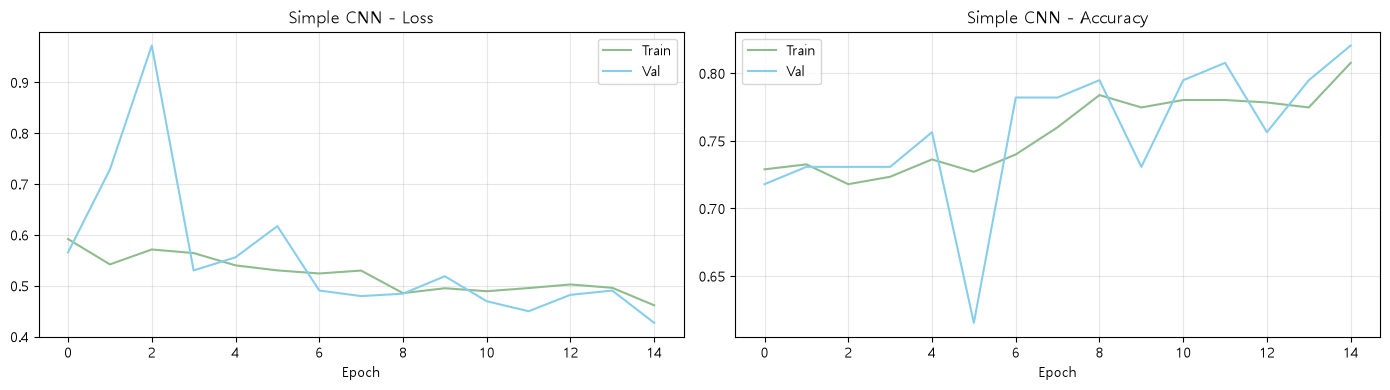

In [9]:
print("=" * 50)
print("기본 CNN 모델 학습")
print("=" * 50)

simple_cnn = SimpleCNN(num_classes=NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_cnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

simple_cnn, simple_history = train_model(
    simple_cnn, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=15, patience=6, device=device
)

plot_history(simple_history, "Simple CNN")


### [필수] 과제 2-1: CNN 구조 분석

1. SimpleCNN 모델에서 각 Conv 블록을 거칠 때마다 특징맵의 크기가 어떻게 변하나요?
   - 답변: 각 Conv2d는 padding=1이라 가로/세로 크기를 그대로 유지하지만, 뒤따르는 MaxPool2d(2,2)가 가로/세로를 절반으로 줄인다. 반대로 채널 수는 32 -> 64 -> 128 -> 256으로 블록마다 2배씩 늘어난다.

2. Global Average Pooling(GAP)을 사용하는 이유는 무엇인가요?
   - 답변: Flatten 후 큰 Fully-Connected층을 쓰는 대신 각 채널의 평균값 하나로 압축하기 때문에 파라미터 수가 크게 줄어 과적합 위험이 낮아지고, 입력 이미지 크기가 달라져도 동일한 구조를 그대로 쓸 수 있다.

3. 학습 곡선을 보고 과적합 여부를 판단하세요.
   - 답변: 위 학습 곡선(Loss/Accuracy)에서 Train과 Val 곡선의 간격을 직접 확인한다. 데이터가 546장으로 매우 적기 때문에 Dropout과 Early Stopping을 적용했음에도 어느 정도 간격이 벌어질 수 있는데, 그 간격이 학습이 진행될수록 계속 커진다면 과적합, 비슷하게 유지된다면 과적합이 심하지 않은 것으로 판단할 수 있다.

## Part 3: 전이학습 - Feature Extraction

사전학습된 모델을 특징 추출기로 사용한다(백본 동결, 분류기만 학습).

In [10]:
def create_feature_extractor(num_classes=2):
    """Feature Extraction 방식의 전이학습 모델: 사전학습 가중치를 동결하고 분류기만 학습"""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )
    return model

feature_extractor = create_feature_extractor(NUM_CLASSES)
trainable_params = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in feature_extractor.parameters())
print(f"Feature Extractor - Trainable: {trainable_params:,} / Total: {total_params:,} "
      f"({trainable_params/total_params*100:.2f}%)")


Feature Extractor - Trainable: 1,026 / Total: 11,177,538 (0.01%)


Feature Extraction 학습


Epoch [ 3/10] | Train: 0.6218/0.6996 | Val: 0.5852/0.7308 | LR: 0.001000


Epoch [ 6/10] | Train: 0.5335/0.7729 | Val: 0.5115/0.7564 | LR: 0.000500


Epoch [ 9/10] | Train: 0.5015/0.7656 | Val: 0.5067/0.7564 | LR: 0.000500


Best model restored (Val Acc: 0.7949)


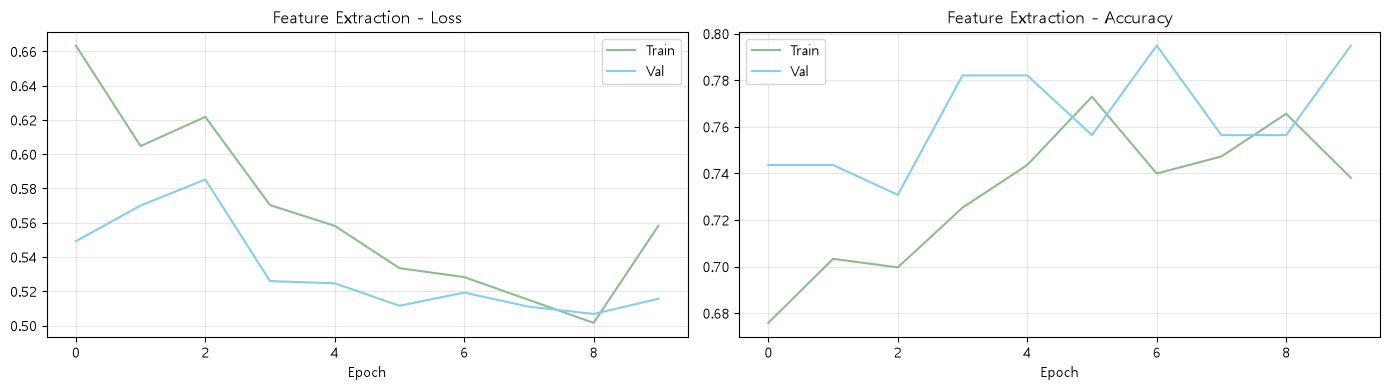

In [11]:
print("=" * 50)
print("Feature Extraction 학습")
print("=" * 50)

feature_extractor = create_feature_extractor(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(feature_extractor.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

feature_extractor, fe_history = train_model(
    feature_extractor, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=10, patience=5, device=device
)

plot_history(fe_history, "Feature Extraction")


## Part 4: 전이학습 - Fine-tuning

사전학습된 모델의 일부 레이어도 함께 학습한다.

In [12]:
def create_finetuning_model(num_classes=2, unfreeze_layers=['layer4', 'fc']):
    """Fine-tuning 방식의 전이학습 모델: 일부 레이어까지 함께 학습"""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for name, module in model.named_children():
        if name in unfreeze_layers:
            for param in module.parameters():
                param.requires_grad = True

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )
    return model

finetuning_model = create_finetuning_model(NUM_CLASSES)
trainable_params = sum(p.numel() for p in finetuning_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in finetuning_model.parameters())
print(f"Fine-tuning - Trainable: {trainable_params:,} / Total: {total_params:,} "
      f"({trainable_params/total_params*100:.2f}%)")


Fine-tuning - Trainable: 8,394,754 / Total: 11,177,538 (75.10%)


Fine-tuning 학습


Epoch [ 3/10] | Train: 0.3791/0.8407 | Val: 0.4925/0.8333 | LR: 0.000100


Epoch [ 6/10] | Train: 0.2524/0.9103 | Val: 0.3735/0.8462 | LR: 0.000050


Epoch [ 9/10] | Train: 0.1957/0.9469 | Val: 0.2790/0.8974 | LR: 0.000050


Best model restored (Val Acc: 0.8974)


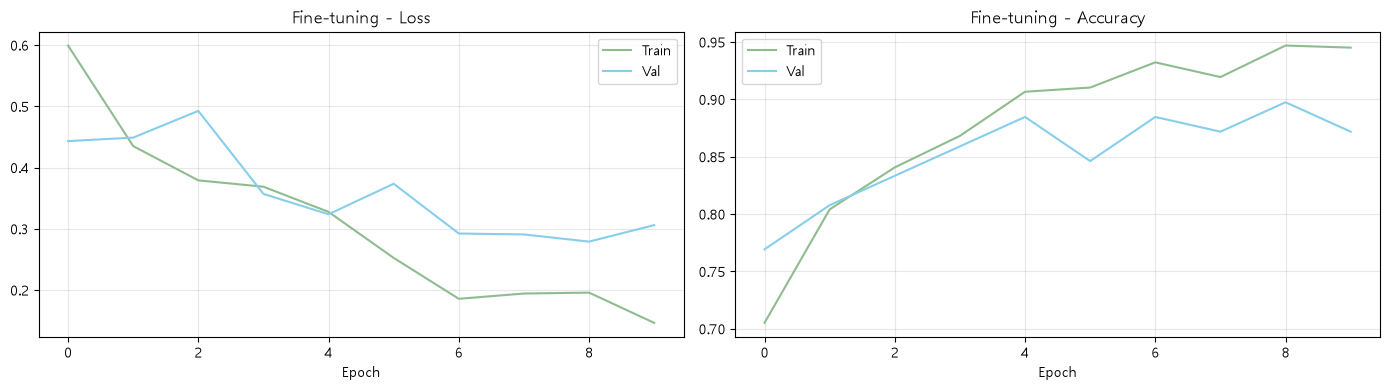

In [13]:
print("=" * 50)
print("Fine-tuning 학습")
print("=" * 50)

finetuning_model = create_finetuning_model(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {'params': finetuning_model.layer4.parameters(), 'lr': 0.0001},
    {'params': finetuning_model.fc.parameters(), 'lr': 0.001}
])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

finetuning_model, ft_history = train_model(
    finetuning_model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=10, patience=5, device=device
)

plot_history(ft_history, "Fine-tuning")


### [필수] 과제 4-1: Feature Extraction vs Fine-tuning 비교

1. Feature Extraction과 Fine-tuning의 차이점을 설명하세요.
   - 답변: Feature Extraction은 사전학습된 가중치를 전부 얼리고 마지막 분류기만 새로 학습한다. Fine-tuning은 사전학습된 가중치를 초기값으로 삼아 지정한 레이어(여기서는 layer4)까지 함께 업데이트한다.

2. 학습 가능한 파라미터 수가 다른 이유는 무엇인가요?
   - 답변: Feature Extraction은 gradient가 흐르는 곳이 새로 붙인 분류기(fc)뿐이라 학습 파라미터가 매우 적다. Fine-tuning은 layer4 전체도 학습 대상에 포함되므로 학습 가능한 파라미터 수가 훨씬 많다(위 출력의 Trainable 값 비교).

3. Fine-tuning에서 레이어별로 다른 학습률을 사용하는 이유는 무엇인가요?
   - 답변: 앞쪽에 가까운 layer는 이미 엣지, 색상 같은 범용적인 특징을 잘 학습한 상태라 큰 학습률로 건드리면 오히려 성능이 나빠질 수 있다. 그래서 새로 붙인 분류기(fc)는 큰 학습률로 적극적으로 학습시키고, 원래 있던 layer4는 작은 학습률로 조금만 조정한다.

4. 어떤 상황에서 Feature Extraction이 더 적합하고, 어떤 상황에서 Fine-tuning이 더 적합한가요?
   - 답변: 이번 BreastMNIST처럼 데이터가 매우 적은 경우(546장)에는 Fine-tuning이 과적합될 위험이 있어 Feature Extraction이 더 안전하다. 반대로 데이터가 충분히 많거나 사전학습 도메인(ImageNet의 일반 사진)과 대상 도메인(의료 이미지)의 차이가 클수록 Fine-tuning으로 더 많은 레이어를 조정하는 편이 유리하다.

## Part 5: 성능 비교 및 평가

In [14]:
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            if len(labels.shape) > 1:
                labels = labels.squeeze(1)
            labels = labels.long()

            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    }
    return metrics, all_preds, all_labels


In [15]:
models_to_evaluate = {
    'Simple CNN': simple_cnn,
    'Feature Extraction': feature_extractor,
    'Fine-tuning': finetuning_model
}

all_results = {}

for name, model in models_to_evaluate.items():
    metrics, preds, labels = evaluate_model(model, test_loader, device)
    all_results[name] = {'metrics': metrics, 'predictions': preds, 'labels': labels}
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")



Simple CNN:
  Accuracy: 0.8013
  Precision: 0.7952
  Recall: 0.8013
  F1 Score: 0.7765



Feature Extraction:
  Accuracy: 0.7756
  Precision: 0.7847
  Recall: 0.7756
  F1 Score: 0.7235



Fine-tuning:
  Accuracy: 0.8590
  Precision: 0.8565
  Recall: 0.8590
  F1 Score: 0.8507


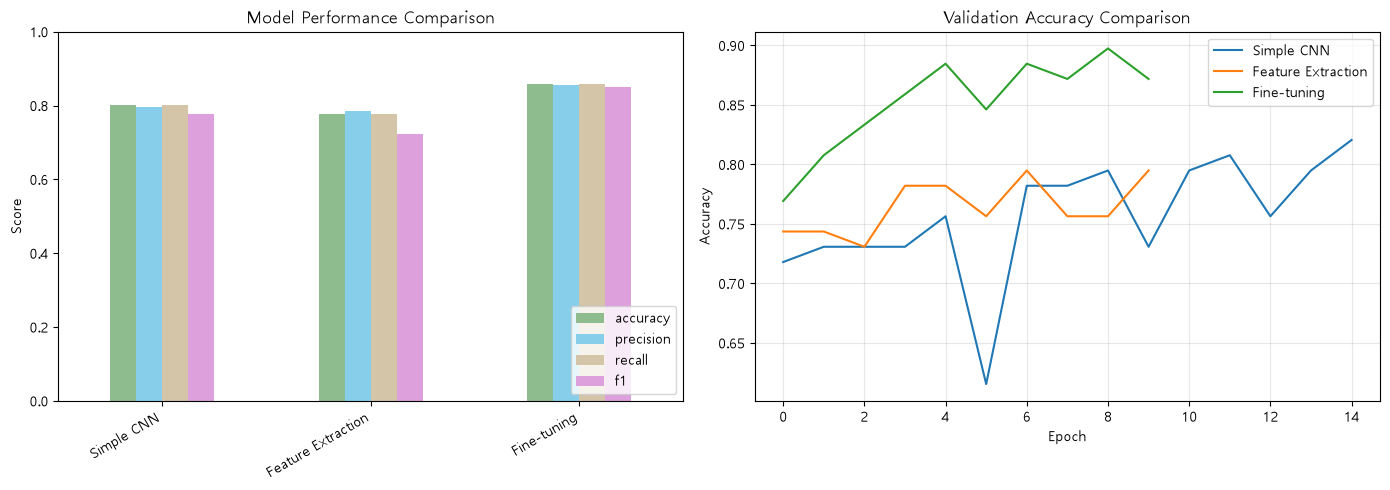


성능 요약:
                    accuracy  precision  recall      f1
Simple CNN            0.8013     0.7952  0.8013  0.7765
Feature Extraction    0.7756     0.7847  0.7756  0.7235
Fine-tuning           0.8590     0.8565  0.8590  0.8507


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_df = pd.DataFrame({name: result['metrics'] for name, result in all_results.items()}).T

metrics_df.plot(kind='bar', ax=axes[0], color=['#8FBC8F', '#87CEEB', '#D4C4A8', '#DDA0DD'])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)

histories = {'Simple CNN': simple_history, 'Feature Extraction': fe_history, 'Fine-tuning': ft_history}
for name, history in histories.items():
    axes[1].plot(history['val_acc'], label=name)
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n성능 요약:")
print(metrics_df.round(4))


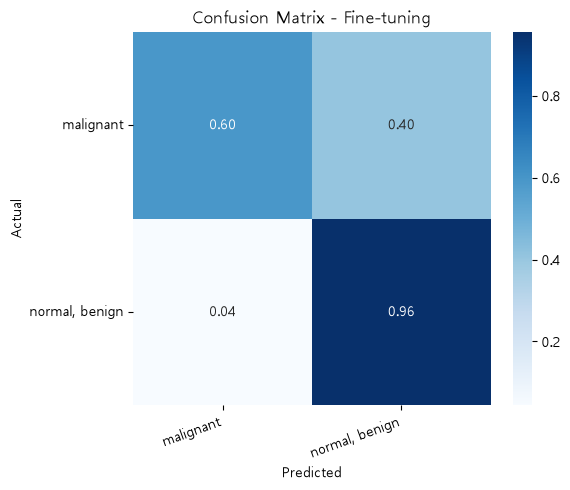

In [17]:
best_model_name = max(all_results.items(), key=lambda x: x[1]['metrics']['accuracy'])[0]
best_result = all_results[best_model_name]

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(best_result['labels'], best_result['predictions'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Part 6: [도전] 다른 사전학습 모델 시도

ResNet18 외에 EfficientNet-B0으로도 전이학습을 시도해 비교한다.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\kimjongmin/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


  0%|          | 0.00/20.5M [00:00<?, ?B/s]

 20%|██        | 4.12M/20.5M [00:00<00:00, 42.3MB/s]

 46%|████▌     | 9.38M/20.5M [00:00<00:00, 49.5MB/s]

 83%|████████▎ | 17.0M/20.5M [00:00<00:00, 63.3MB/s]

100%|██████████| 20.5M/20.5M [00:00<00:00, 61.2MB/s]

Epoch [ 3/8] | Train: 0.5105/0.7546 | Val: 0.4275/0.8590 | LR: 0.001000


Early stopping at epoch 6
Best model restored (Val Acc: 0.8846)


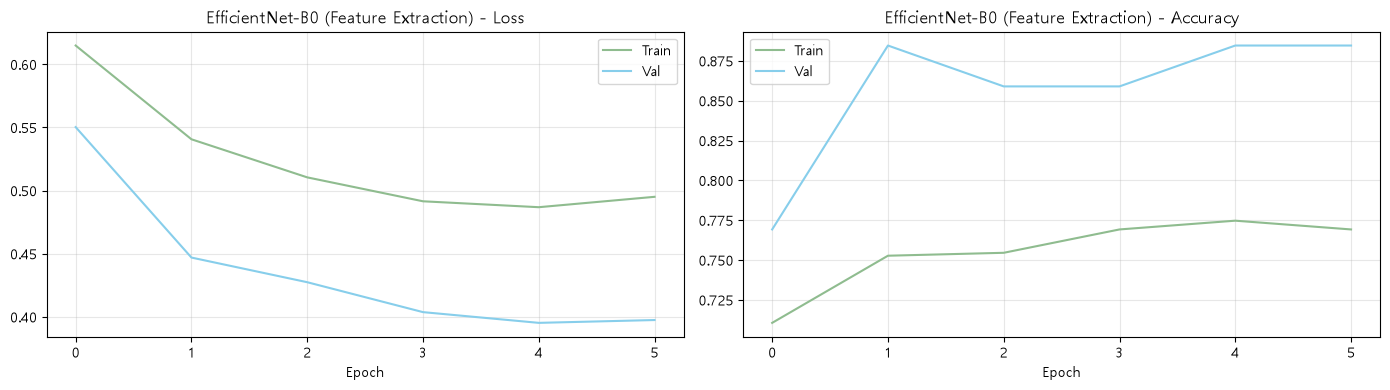


EfficientNet-B0:
  Accuracy: 0.7628
  F1 Score: 0.7290


In [18]:
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in efficientnet.parameters():
    param.requires_grad = False
efficientnet.classifier[-1] = nn.Linear(1280, NUM_CLASSES)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.classifier.parameters(), lr=0.001)

efficientnet, eff_history = train_model(
    efficientnet, train_loader, val_loader,
    criterion, optimizer,
    num_epochs=8, patience=4, device=device
)

plot_history(eff_history, "EfficientNet-B0 (Feature Extraction)")

eff_metrics, eff_preds, eff_labels = evaluate_model(efficientnet, test_loader, device)
print(f"\nEfficientNet-B0:")
print(f"  Accuracy: {eff_metrics['accuracy']:.4f}")
print(f"  F1 Score: {eff_metrics['f1']:.4f}")


## CNN/전이학습 실습 리포트

### 1. 실험 요약

| 모델 | Test Accuracy | Test F1 | 학습 가능 파라미터 비율 |
|------|---------------|---------|----------------|
| Simple CNN | 80.13% | 0.7765 | 100% (처음부터 학습) |
| Feature Extraction | 77.56% | 0.7235 | 0.01% (분류기만) |
| Fine-tuning | 85.90% | 0.8507 | 75.10% (layer4 + fc) |
| EfficientNet-B0 (Feature Extraction) | 76.28% | 0.7290 | 분류기만 |

BreastMNIST(학습 546장)라는 적은 데이터에서는 백본 일부(layer4)까지 함께 학습한 Fine-tuning이 가장 좋은 성능을 보였고, 분류기만 학습한 두 Feature Extraction 모델(ResNet18, EfficientNet-B0)은 서로 비슷한 수준에 머물렀다.

### 2. CNN 구조 분석
- 합성곱 연산의 역할: 작은 커널을 이미지 전체에 슬라이딩하며 지역적인 패턴(엣지, 텍스처 등)을 추출한다. 같은 커널을 위치마다 재사용하므로 완전연결층보다 파라미터 수가 훨씬 적고, 이미지 내 위치가 달라져도 같은 패턴을 인식할 수 있다.
- 풀링 연산의 역할: 특징맵의 공간 크기를 줄여 연산량과 파라미터 수를 줄이고, 약간의 위치 변화에도 강건하게 만든다.
- 채널 수가 증가하는 이유: 앞쪽 층은 엣지처럼 단순한 저수준 특징 몇 가지만 필요하지만, 뒤로 갈수록 이 저수준 특징들을 조합한 고수준 특징(모양, 패턴)을 표현해야 하므로 채널 수를 늘려 더 많은 특징 조합을 담을 공간을 확보한다.

### 3. 전이학습 분석
- Feature Extraction의 장단점: 학습 파라미터가 적어 빠르고, 데이터가 적어도(BreastMNIST 546장) 과적합 위험이 낮다. 다만 사전학습 특징을 그대로 쓰기 때문에 도메인 차이가 크면 성능에 한계가 있다.
- Fine-tuning의 장단점: 일부 레이어까지 데이터에 맞게 조정되므로 잠재적으로 더 높은 성능을 낼 수 있지만, 학습 파라미터가 많아 데이터가 적을 때는 과적합 위험도 함께 커진다.
- 적합한 사용 시나리오: 데이터가 적고 사전학습 도메인과 유사하면 Feature Extraction, 데이터가 충분하거나 도메인 차이가 크면 Fine-tuning이 유리하다.

### 4. 데이터 증강 효과
- 사용한 데이터 증강 기법: RandomHorizontalFlip, RandomRotation(15도)
- 데이터 증강의 효과: 원본 이미지를 좌우 반전하거나 살짝 회전시켜 매 epoch마다 조금씩 다른 이미지를 보여주는 효과를 낸다. 546장뿐인 학습 데이터에서 모델이 특정 방향·각도에만 맞춰 암기하는 것을 막아 일반화 성능을 높이는 데 도움이 된다.

### 5. 개선 제안
1. BreastMNIST 대신 더 큰 MedMNIST 서브셋(PathMNIST 등)이나 GPU 환경에서 더 많은 epoch으로 재실험
2. Fine-tuning에서 unfreeze하는 레이어 범위(layer3+layer4 등)를 바꿔가며 비교
3. 클래스 불균형(malignant vs normal,benign)을 고려한 class weight 적용

### 6. 배운 점

CNN을 직접 구현하면서 Conv-BatchNorm-ReLU-MaxPool 블록을 쌓을 때마다 공간 크기는 줄고 채널 수는 늘어나는 패턴이 왜 반복되는지 체감했다. 특히 인상 깊었던 부분은 Feature Extraction과 Fine-tuning의 학습 가능 파라미터 수 차이를 코드로 직접 출력해보니, "학습 범위"라는 추상적인 말이 실제로는 몇 개의 레이어를 얼리느냐라는 구체적인 선택이라는 걸 알게 됐다는 점이다. 데이터가 아주 적은 BreastMNIST 같은 상황에서는 무조건 모델 전체를 학습시키는 것이 능사가 아니라, 오히려 백본을 얼려두는 Feature Extraction이 더 안정적일 수 있다는 것도 실험을 통해 실감했다.